Diabetes using ANN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
%matplotlib inline

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
15,7,100,0,0,0,30.0,0.484,32,0
16,0,118,84,47,230,45.8,0.551,31,1
17,1,103,30,38,83,43.3,0.183,33,0
18,3,126,88,41,235,39.3,0.704,49,1
19,2,99,68,21,0,24.6,0.334,26,0


In [6]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
7,10,115,0,0,0,35.3,0.134,29,0
15,7,100,0,0,0,30.0,0.484,32,0
11,10,168,74,0,0,38.0,0.537,34,1
4,0,137,40,35,168,43.1,2.288,33,1
10,4,110,92,0,0,37.6,0.191,30,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    20 non-null     int64  
 1   Glucose        20 non-null     int64  
 2   BloodPressure  20 non-null     int64  
 3   SkinThickness  20 non-null     int64  
 4   Insulin        20 non-null     int64  
 5   BMI            20 non-null     float64
 6   DPF            20 non-null     float64
 7   Age            20 non-null     int64  
 8   Outcome        20 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 1.5 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Outcome
count,20.000000,20.00000,20.00000,20.000000,20.000000,20.000000,20.00000,20.000000,20.000000
mean,4.350000,129.55000,62.30000,19.400000,123.100000,30.935000,0.52440,38.050000,0.550000
std,3.483419,35.52238,26.66182,17.780533,217.393144,9.909712,0.51362,12.006468,0.510418
min,0.000000,78.00000,0.00000,0.000000,0.000000,0.000000,0.13400,21.000000,0.000000
25%,1.000000,102.25000,57.50000,0.000000,0.000000,26.400000,0.19850,30.000000,0.000000
50%,3.500000,121.50000,69.00000,22.000000,0.000000,30.300000,0.37450,32.500000,1.000000
75%,7.250000,152.50000,75.50000,35.000000,169.750000,37.700000,0.59700,50.250000,1.000000
max,10.000000,197.00000,96.00000,47.000000,846.000000,45.800000,2.28800,59.000000,1.000000


In [9]:
df.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

In [10]:
df.shape

(20, 9)

In [11]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DPF', 'Age', 'Outcome'],
      dtype='object')

In [12]:
X=df.drop('Outcome',axis=1).values
y=df['Outcome'].values

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=30)

In [15]:
X_test

array([[ 10.   , 168.   ,  74.   ,   0.   ,   0.   ,  38.   ,   0.537,
         34.   ],
       [  6.   , 148.   ,  72.   ,  35.   ,   0.   ,  33.6  ,   0.627,
         50.   ],
       [  7.   , 100.   ,   0.   ,   0.   ,   0.   ,  30.   ,   0.484,
         32.   ],
       [  5.   , 166.   ,  72.   ,  19.   , 175.   ,  25.8  ,   0.587,
         51.   ],
       [  8.   , 125.   ,  96.   ,   0.   ,   0.   ,   0.   ,   0.232,
         54.   ],
       [  3.   ,  78.   ,  50.   ,  32.   ,  88.   ,  31.   ,   0.248,
         26.   ]])

In [16]:
X_train

array([[4.000e+00, 1.100e+02, 9.200e+01, 0.000e+00, 0.000e+00, 3.760e+01,
        1.910e-01, 3.000e+01],
       [2.000e+00, 1.970e+02, 7.000e+01, 4.500e+01, 5.430e+02, 3.050e+01,
        1.580e-01, 5.300e+01],
       [0.000e+00, 1.180e+02, 8.400e+01, 4.700e+01, 2.300e+02, 4.580e+01,
        5.510e-01, 3.100e+01],
       [1.000e+00, 8.900e+01, 6.600e+01, 2.300e+01, 9.400e+01, 2.810e+01,
        1.670e-01, 2.100e+01],
       [1.000e+00, 8.500e+01, 6.600e+01, 2.900e+01, 0.000e+00, 2.660e+01,
        3.510e-01, 3.100e+01],
       [3.000e+00, 1.260e+02, 8.800e+01, 4.100e+01, 2.350e+02, 3.930e+01,
        7.040e-01, 4.900e+01],
       [8.000e+00, 1.830e+02, 6.400e+01, 0.000e+00, 0.000e+00, 2.330e+01,
        6.720e-01, 3.200e+01],
       [1.000e+01, 1.150e+02, 0.000e+00, 0.000e+00, 0.000e+00, 3.530e+01,
        1.340e-01, 2.900e+01],
       [1.000e+01, 1.390e+02, 8.000e+01, 0.000e+00, 0.000e+00, 2.710e+01,
        1.441e+00, 5.700e+01],
       [0.000e+00, 1.370e+02, 4.000e+01, 3.500e+01, 1.6

In [17]:
y_test

array([1, 1, 0, 1, 1, 1])

In [18]:
y_train

array([0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0])

In [22]:
X_train.shape

(14, 8)

In [21]:
y_train.shape

(14,)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [28]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [32]:
joblib.dump(scaler,"scaler.pk1")

['scaler.pk1']

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,InputLayer,Dropout

In [34]:
model=Sequential([Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
                  Dense(8,activation='relu'),
                  Dense(1,activation='sigmoid')
                 ])

C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
             )

In [39]:
model.fit(x=X_train,y=
          y_train,epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9286 - loss: 0.2174 - val_accuracy: 0.6667 - val_loss: 1.1440
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9286 - loss: 0.2157 - val_accuracy: 0.6667 - val_loss: 1.1470
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9286 - loss: 0.2139 - val_accuracy: 0.6667 - val_loss: 1.1502
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9286 - loss: 0.2121 - val_accuracy: 0.6667 - val_loss: 1.1533
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9286 - loss: 0.2104 - val_accuracy: 0.6667 - val_loss: 1.1563
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9286 - loss: 0.2087 - val_accuracy: 0.6667 - val_loss: 1.1593
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9286 - loss: 0.2070 - val_accuracy: 0.6667 - val_loss: 1.1623
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9286 - loss: 0.2053 - val_accuracy: 0.6667 - v

In [40]:
model_loss=pd.DataFrame(model.history.history)

<Axes: >

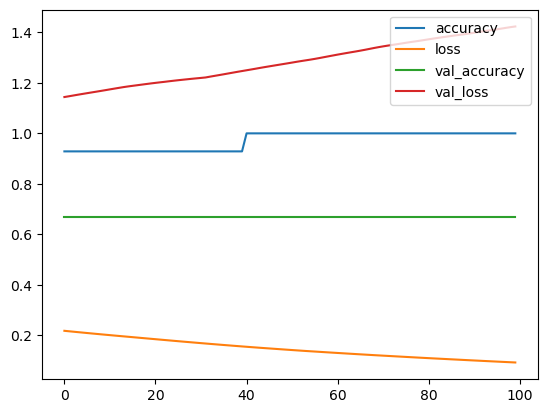

In [41]:
model_loss.plot()

In [42]:
# early stopping
model=Sequential([Dense(16,activation='relu',input_shape=(X_train.shape[1],)),
                  Dense(8,activation='relu'),
                  Dense(1,activation='sigmoid')
                 ])

C:\Users\Vennela\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=50)

In [46]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy']
             )

In [49]:
history=model.fit(x=X_train,
          y=y_train,
          epochs=100,
          validation_data=(X_test, y_test),
          callbacks=[early_stop]
          )

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 1.0000 - loss: 0.2590 - val_accuracy: 0.3333 - val_loss: 1.0325
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 0.2554 - val_accuracy: 0.3333 - val_loss: 1.0352
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.2518 - val_accuracy: 0.3333 - val_loss: 1.0379
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss: 0.2482 - val_accuracy: 0.3333 - val_loss: 1.0405
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 1.0000 - loss: 0.2447 - val_accuracy: 0.3333 - val_loss: 1.0433
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 1.0000 - loss: 0.2412 - val_accuracy: 0.3333 - val_loss: 1.0464
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 1.0000 - loss: 0.2378 - val_accuracy: 0.3333 - val_loss: 1.0495
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 1.0000 - loss: 0.2344 - val_accuracy: 0.3333 - v

In [50]:
score=model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3333 - loss: 1.1621


In [51]:
print(model.metrics_names)
print(score)

['loss', 'compile_metrics']
[1.162096381187439, 0.3333333432674408]


In [52]:
from keras.models import load_model
model.save('model.keras')

In [53]:
model_loss = pd.DataFrame(model.history.history)

<Axes: >

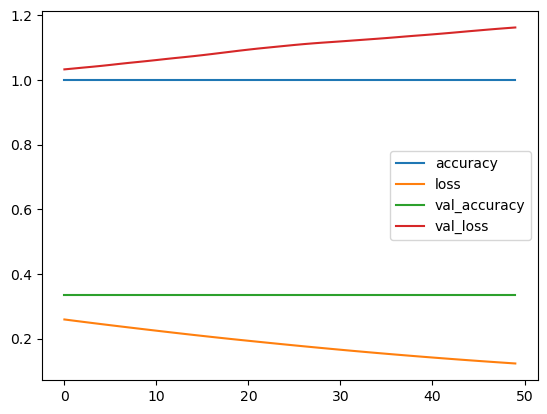

In [54]:
model_loss.plot()

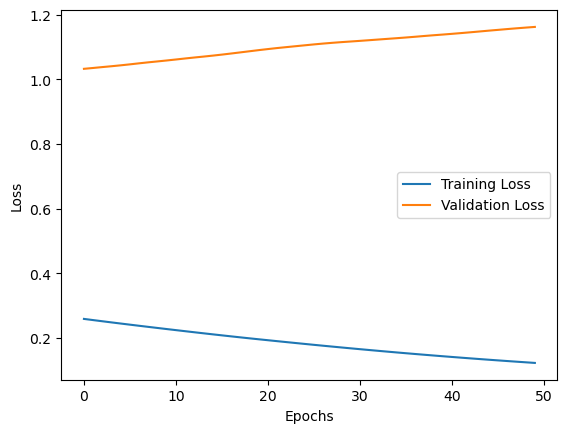

In [55]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

In [58]:
sample = np.array([[6,148,72,35,33.6,0,0.627,0.1]])
sample = scaler.transform(sample)

model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


array([[1.]], dtype=float32)

In [59]:
model.save('model.keras')

In [60]:
import pickle

In [61]:
filename='model.keras'
pickle.dump(model,open(filename,'wb'))

In [62]:
loaded_model=pickle.load(open('model.keras','rb'))

In [64]:
sample=np.array([[6,148,72,35,0,33.6,0.627,0.1]])
sample=scaler.transform(sample)

In [65]:
loaded_model.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


array([[1.]], dtype=float32)

In [66]:
import os
os.getcwd()

'C:\\Users\\Vennela\\Documents\\ANN_diabetes'